# Common imports

In [1]:
%matplotlib inline
import os
import sys
import glob
import re
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from PIL import Image

# Provided functions
### Image loading and saving

In [2]:
def LoadFaceImages(pathname, subject_name, num_images):
    """
    Load the set of face images.  
    The routine returns
        ambimage: image illuminated under the ambient lighting
        imarray: a 3-D array of images, h x w x Nimages
        lightdirs: Nimages x 3 array of light source directions
    """

    def load_image(fname):
        return np.asarray(Image.open(fname))

    def fname_to_ang(fname):
        yale_name = os.path.basename(fname)
        return int(yale_name[12:16]), int(yale_name[17:20])

    def sph2cart(az, el, r):
        rcos_theta = r * np.cos(el)
        x = rcos_theta * np.cos(az)
        y = rcos_theta * np.sin(az)
        z = r * np.sin(el)
        return x, y, z

    ambimage = load_image(
        os.path.join(pathname, subject_name + '_P00_Ambient.pgm'))
    im_list = glob.glob(os.path.join(pathname, subject_name + '_P00A*.pgm'))
    if num_images <= len(im_list):
        im_sub_list = np.random.choice(im_list, num_images, replace=False)
    else:
        print(
            'Total available images is less than specified.\nProceeding with %d images.\n'
            % len(im_list))
        im_sub_list = im_list
    im_sub_list.sort()
    imarray = np.stack([load_image(fname) for fname in im_sub_list], axis=-1)
    Ang = np.array([fname_to_ang(fname) for fname in im_sub_list])

    x, y, z = sph2cart(Ang[:, 0] / 180.0 * np.pi, Ang[:, 1] / 180.0 * np.pi, 1)
    lightdirs = np.stack([y, z, x], axis=-1)
    return ambimage, imarray, lightdirs

In [3]:
def save_outputs(subject_name, albedo_image, surface_normals):
    im = Image.fromarray((albedo_image*255).astype(np.uint8))
    im.save("%s_albedo.jpg" % subject_name)
    im = Image.fromarray((surface_normals[:,:,0]*128+128).astype(np.uint8))
    im.save("%s_normals_x.jpg" % subject_name)
    im = Image.fromarray((surface_normals[:,:,1]*128+128).astype(np.uint8))
    im.save("%s_normals_y.jpg" % subject_name)
    im = Image.fromarray((surface_normals[:,:,2]*128+128).astype(np.uint8))
    im.save("%s_normals_z.jpg" % subject_name)

### Plot the height map

In [725]:
def set_aspect_equal_3d(ax):
    """https://stackoverflow.com/questions/13685386"""
    """Fix equal aspect bug for 3D plots."""
    xlim = ax.get_xlim3d()
    ylim = ax.get_ylim3d()
    zlim = ax.get_zlim3d()
    from numpy import mean
    xmean = mean(xlim)
    ymean = mean(ylim)
    zmean = mean(zlim)
    plot_radius = max([
        abs(lim - mean_)
        for lims, mean_ in ((xlim, xmean), (ylim, ymean), (zlim, zmean))
        for lim in lims
    ])
    ax.set_xlim3d([xmean - plot_radius, xmean + plot_radius])
    ax.set_ylim3d([ymean - plot_radius, ymean + plot_radius])
    ax.set_zlim3d([zmean - plot_radius, zmean + plot_radius])


def display_output(albedo_image, height_map):
    fig = plt.figure()
    plt.imshow(albedo_image, cmap='gray')
    plt.axis('off')
    
    fig = plt.figure(figsize=(10, 10))
    ax = fig.gca(projection='3d')
    ax.view_init(20, 20)
    X = np.arange(albedo_image.shape[0])
    Y = np.arange(albedo_image.shape[1])
    X, Y = np.meshgrid(Y, X)
    H = np.flipud(np.fliplr(height_map))
    A = np.flipud(np.fliplr(albedo_image))
    A = np.stack([A, A, A], axis=-1)
    ax.xaxis.set_ticks([])
    ax.xaxis.set_label_text('Z')
    ax.yaxis.set_ticks([])
    ax.yaxis.set_label_text('X')
    ax.zaxis.set_ticks([])
    ax.yaxis.set_label_text('Y')
    surf = ax.plot_surface(
        H, X, Y, cmap='gray', facecolors=A, linewidth=0, antialiased=False)
    set_aspect_equal_3d(ax)

### Plot the surface norms. 

In [5]:
def plot_surface_normals(surface_normals):
    """
    surface_normals: h x w x 3 matrix.
    """
    fig = plt.figure()
    ax = plt.subplot(1, 3, 1)
    ax.axis('off')
    ax.set_title('X')
    im = ax.imshow(surface_normals[:,:,0])
    ax = plt.subplot(1, 3, 2)
    ax.axis('off')
    ax.set_title('Y')
    im = ax.imshow(surface_normals[:,:,1])
    ax = plt.subplot(1, 3, 3)
    ax.axis('off')
    ax.set_title('Z')
    im = ax.imshow(surface_normals[:,:,2])

# Your implementation

In [6]:
def preprocess(ambimage, imarray):
    """
    preprocess the data: 
        1. subtract ambient_image from each image in imarray.
        2. make sure no pixel is less than zero.
        3. rescale values in imarray to be between 0 and 1.
    Inputs:
        ambimage: h x w
        imarray: h x w x Nimages
    Outputs:
        processed_imarray: h x w x Nimages
    """
    processed_imarray = imarray - np.expand_dims(ambimage, 2)
    processed_imarray[processed_imarray < 0] = 0
    processed_imarray = processed_imarray / processed_imarray.max()
    return processed_imarray

In [22]:
def photometric_stereo(imarray, light_dirs):
    """
    Inputs:
        imarray:  h x w x N images
        light_dirs: Nimages x 3
    Outputs:
        albedo_image: h x w
        surface_norms: h x w x 3
    """
    h, w, _ = imarray.shape
    surface_normals = np.zeros((h, w, 3))
    albedo_image = np.zeros((h, w))
    ps_inv = light_dirs.T @ light_dirs
    for i in range(h):
        for j in range(w):
            N = np.linalg.solve(ps_inv, light_dirs.T @ imarray[i, j])
            mag_N = np.linalg.norm(N)
            surface_normals[i, j] = N / mag_N
            albedo_image[i, j] = np.pi * mag_N
    return albedo_image, surface_normals

In [799]:
id = 0
def photometric_stereo2(imarray, light_dirs):
    """
    Inputs:
        imarray:  h x w x N images
        light_dirs: Nimages x 3
    Outputs:
        albedo_image: h x w
        surface_norms: h x w x 3
    """
    global id
    h, w, _ = imarray.shape
    #niter = 20
    #alpha = 1e-2
    eps = 1e-4
    #surface_normals = np.zeros((niter, h, w, 3))
    #albedo_image = np.zeros((niter, h, w))
    surface_normals = np.zeros((h, w, 3))
    albedo_image = np.zeros((h, w))
    ps_inv = light_dirs.T @ light_dirs
    #plot_surface_normals_albedo(surface_normals[0], albedo_image[0])
    for i in range(h):
        for j in range(w):
            #N = np.zeros(3)
            #for iter in range(niter):
            #N = N - alpha*light_dirs.T@(light_dirs@N - imarray[i, j])
            N = np.linalg.solve(ps_inv, light_dirs.T @ imarray[i, j])
            mag_N = np.linalg.norm(N) + eps
            #print(iter, N / mag_N, mag_N)
            surface_normals[i, j] = N / mag_N
            albedo_image[i, j] = np.pi * mag_N
            #surface_normals[iter, i, j] = N / mag_N
            #albedo_image[iter, i, j] = np.pi * mag_N
    #for iter in range(niter):
        #print(np.linalg.norm(surface_normals[iter]), np.linalg.norm(albedo_image[iter]))
        #plot_surface_normals_albedo(surface_normals[iter], albedo_image[iter])
    #plot_surface_normals_albedo(surface_normals, albedo_image)
        
    return albedo_image, surface_normals

In [789]:
def get_surface(surface_normals, integration_method='fc'):
    """
    Inputs:
        surface_normals:h x w x 3
        integration_method: string in ['average', 'column', 'row', 'random']
    Outputs:
        height_map: h x w
    """
    eps = 1e-4
    p = surface_normals[:,:,0] / (surface_normals[:,:,2] + eps)
    q = surface_normals[:,:,1] / (surface_normals[:,:,2] + eps)
    z = np.zeros_like(p)
    if integration_method == 'average':
        for y in range(1, z.shape[1]):
            z[0,y] = z[0,y-1] - q[0,y]
        for y in range(z.shape[1]):
            for x in range(1, z.shape[0]):
                z[x,y] = z[x-1,y] - p[x,y]
    else:
        #P, Q = np.fft.fft2(p), np.fft.fft2(q)
        #i = np.array([0+1j])[0]
        #z = z.astype(np.clongdouble)
        #for u in range(P.shape[0]):
        #    for v in range(P.shape[1]):
        #        if u**2 + v**2 > 0:
        #            z[u,v] = (i*u*P[u,v] + i*v*Q[u,v])/(u**2 + v**2)
        #z = np.real(np.fft.ifft2(z))
        
        i = np.array([0+1j])[0]
        #wx, wy = np.meshgrid(np.linspace(-np.pi/2, np.pi/2, p.shape[1]), np.linspace(-np.pi/2, np.pi/2, p.shape[0]));
        wx, wy = np.meshgrid(np.arange(p.shape[1]), np.arange(p.shape[0]))
        # Quadrant shift to put zero frequency at the appropriate edge
        #wx = np.fft.ifftshift(2*np.pi*wx) / p.shape[0]
        #wy = np.fft.ifftshift(2*np.pi*wy) / p.shape[1]
        wx = 2*np.pi*wx / p.shape[0]
        wy = 2*np.pi*wy / p.shape[1]

        # Fourier transforms of gradients

        P = np.fft.fft2(p)
        Q = np.fft.fft2(q)

        # Integrate in the frequency domain by phase shifting by pi/2 and weighting
        # the Fourier coefficients by their frequencies in x and y and then
        # dividing by the squared frequency.  To avoid division by 0 eps is added
        # to the denominator.

        # Equation 21:

        h = (i*wx*P + i*wy*Q)/(wx**2 + wy**2 + eps) #depthsfft

        # Reconstruction

        #z = np.real(np.fft.ifft2(depthsfft))
        z = np.abs(np.fft.ifft2(h)) #depthsfft
        
    return z #height_map

# Main function

In [668]:
root_path = 'croppedyale/'
subject_name = 'yaleB01'
integration_method = 'average'
save_flag = True

full_path = '%s%s' % (root_path, subject_name)
ambient_image, imarray, light_dirs = LoadFaceImages(full_path, subject_name, 64)
imarray.shape, light_dirs.shape, light_dirs[1]

((192, 168, 64), (64, 3), array([0.        , 0.34202014, 0.93969262]))

In [669]:
processed_imarray = preprocess(ambient_image, imarray)
processed_imarray.shape

(192, 168, 64)

In [445]:
processed_imarray.max()

1.0

In [23]:
albedo_image, surface_normals = photometric_stereo(processed_imarray, light_dirs)

In [ ]:
height_map = get_surface(surface_normals, 'average')

In [ ]:
if save_flag:
    save_outputs(subject_name, albedo_image, surface_normals)

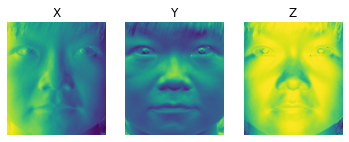

In [24]:
plot_surface_normals(surface_normals)

In [533]:
def plot_surface_normals_albedo(surface_normals, albedo_image, k=2):
    """
    surface_normals: h x w x 3 matrix.
    """
    h, w, _ = surface_normals.shape
    x, y = np.meshgrid(np.arange(w), np.arange(h))
    print(x.shape, surface_normals.shape)
    p, q = surface_normals[:,:,0]/surface_normals[:,:,2], surface_normals[:,:,1]/surface_normals[:,:,2]
    plt.figure(figsize=(20,10))
    plt.gray()
    plt.subplot(121)
    plt.quiver(x[::k, ::k], y[::k, ::k], #np.flipud(np.fliplr(
               np.flipud(np.fliplr(p[::k, ::k])), np.flipud(np.fliplr(q[::k, ::k])),  
               units='xy', angles='xy', scale=0.25)
    plt.title('Surface Normals', size=20)
    plt.axis('off')
    plt.subplot(122)
    plt.imshow(albedo_image)
    plt.axis('off')
    plt.title('Albedo', size=20)
    plt.tight_layout()
    plt.show()

In [701]:
albedo_image, surface_normals = photometric_stereo2(processed_imarray, light_dirs)

(192, 168) (192, 168, 3)


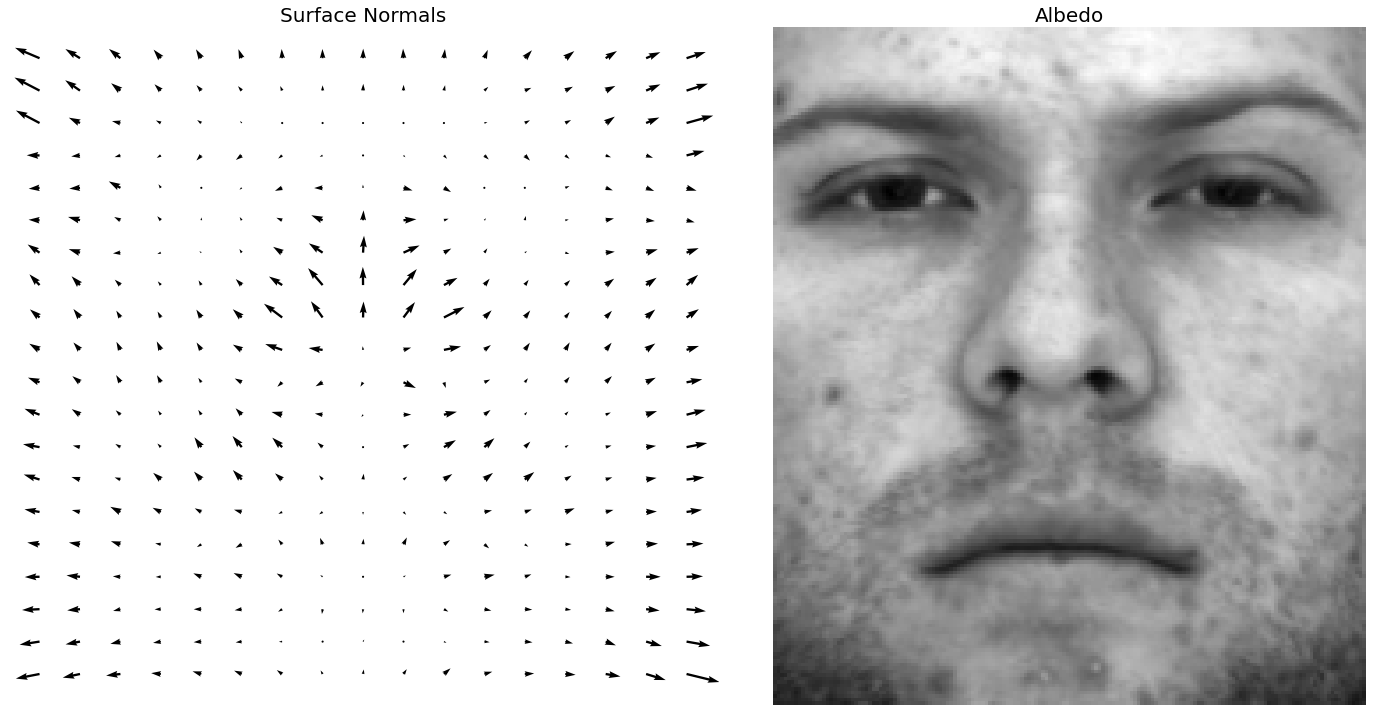

(192, 168) (192, 168, 3)


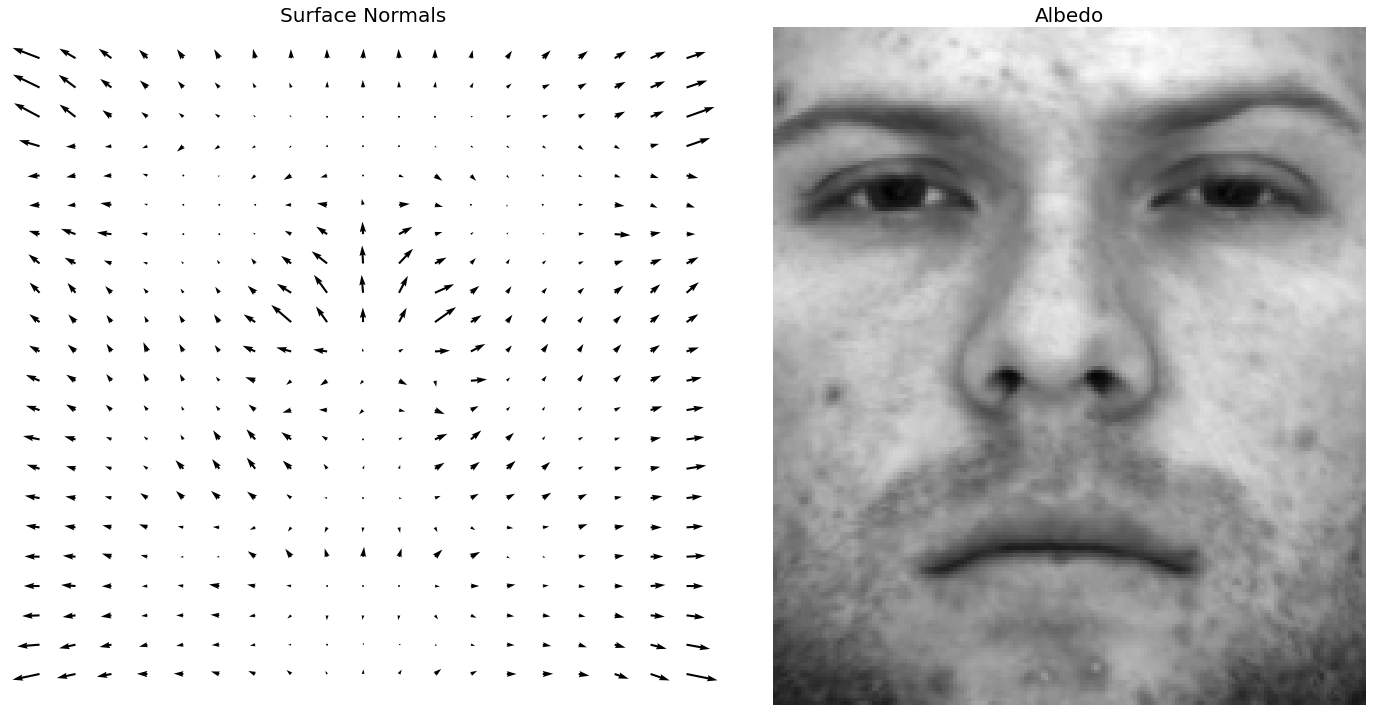

(192, 168) (192, 168, 3)


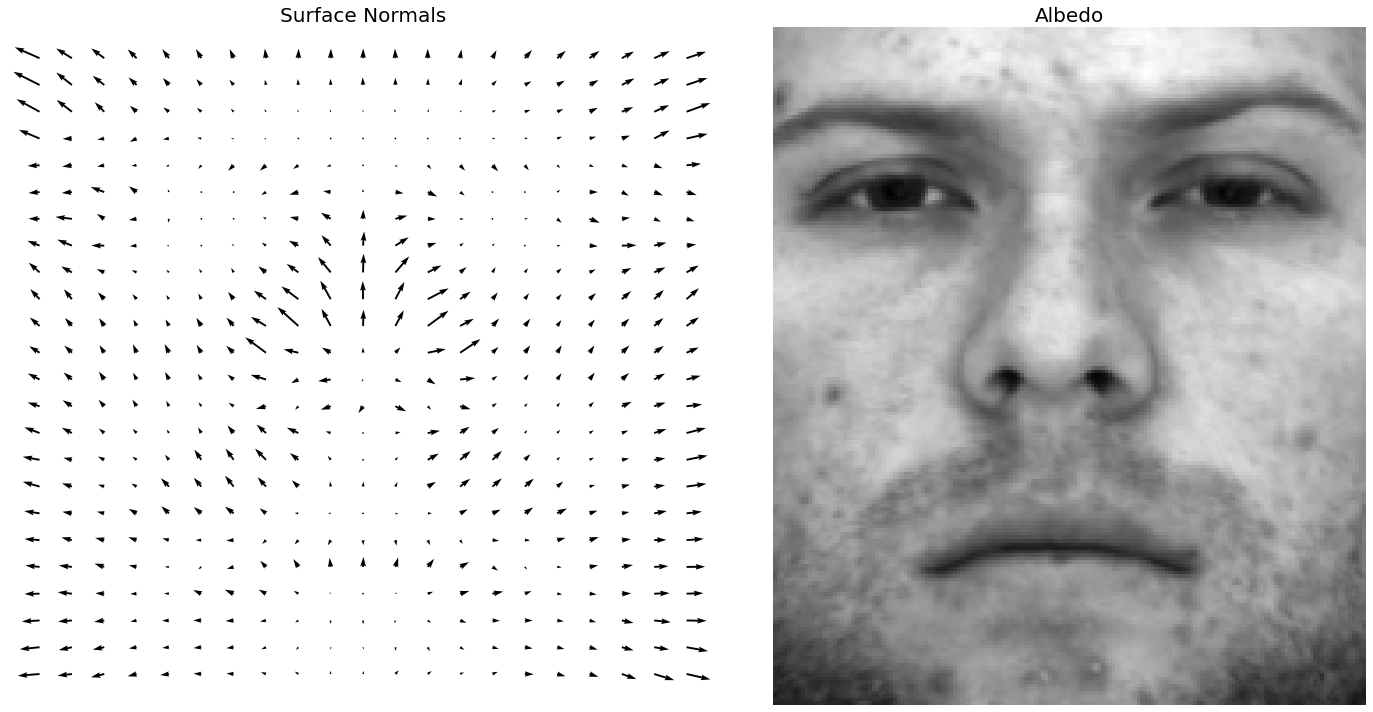

(192, 168) (192, 168, 3)


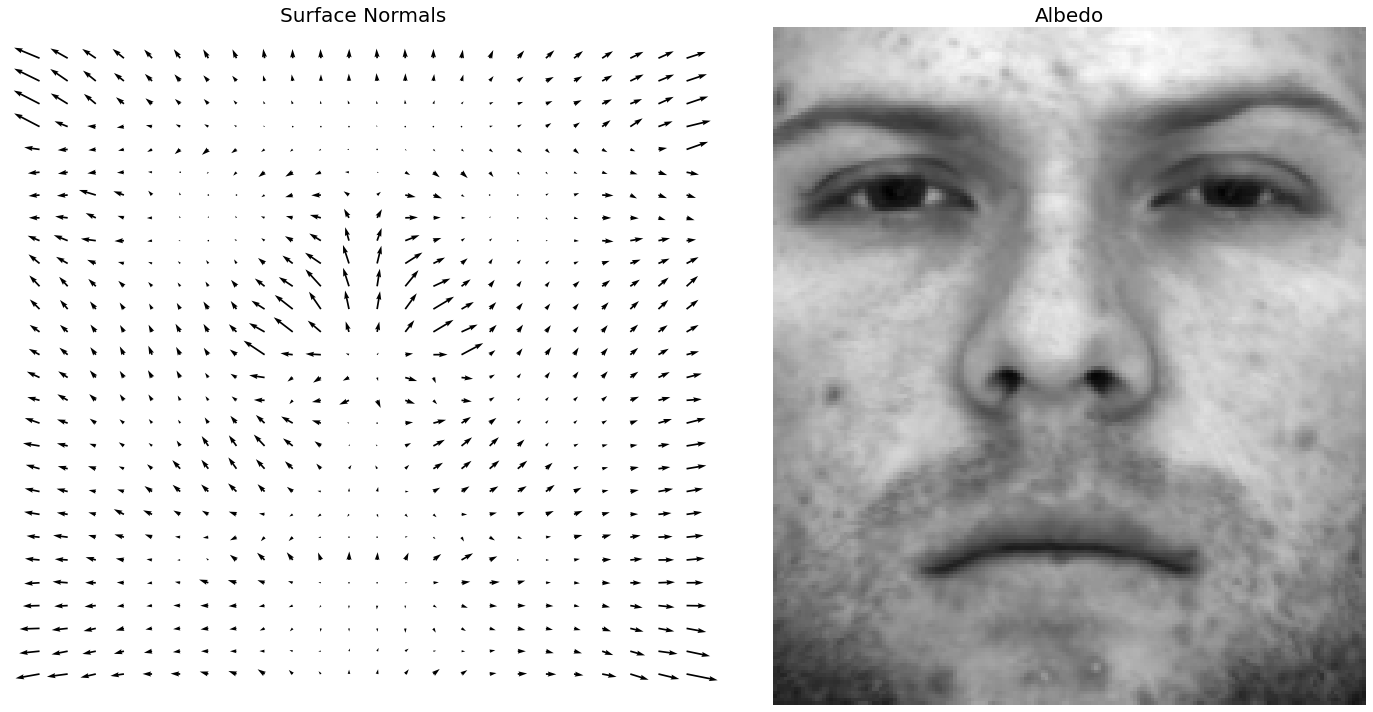

(192, 168) (192, 168, 3)


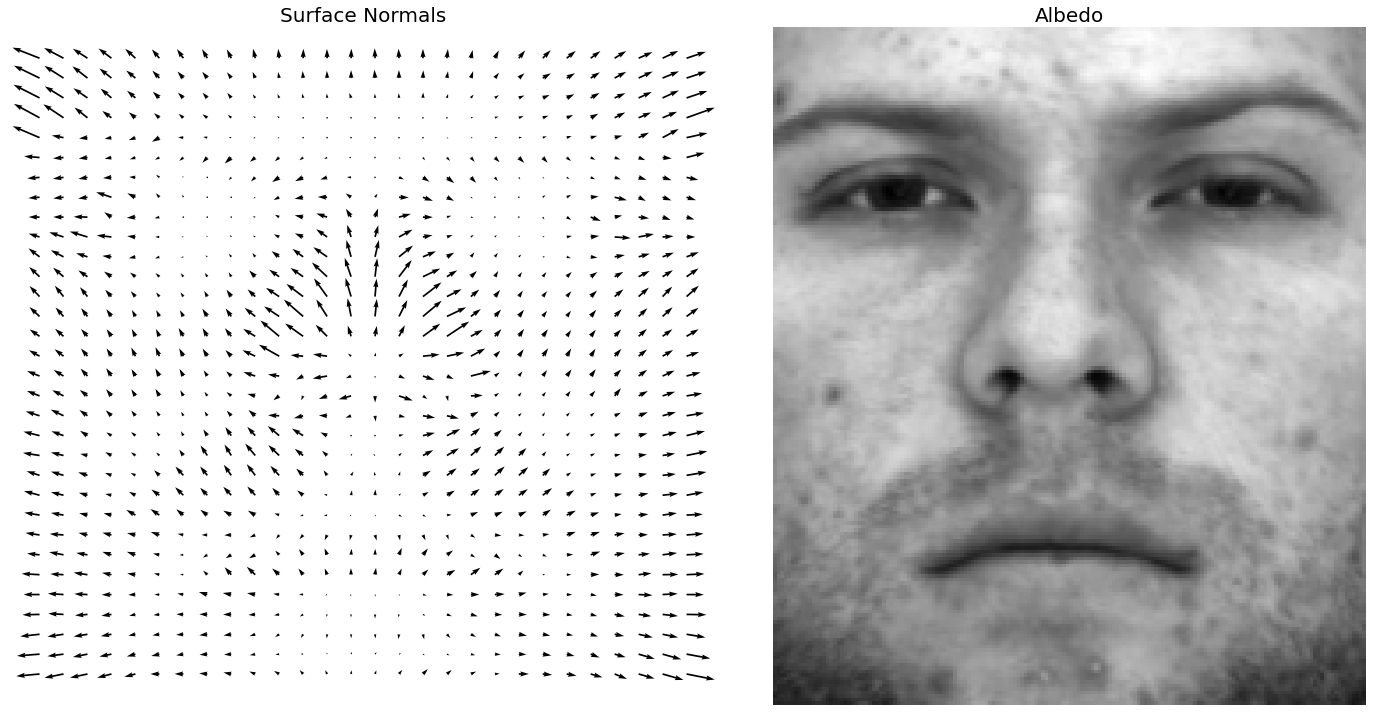

(192, 168) (192, 168, 3)


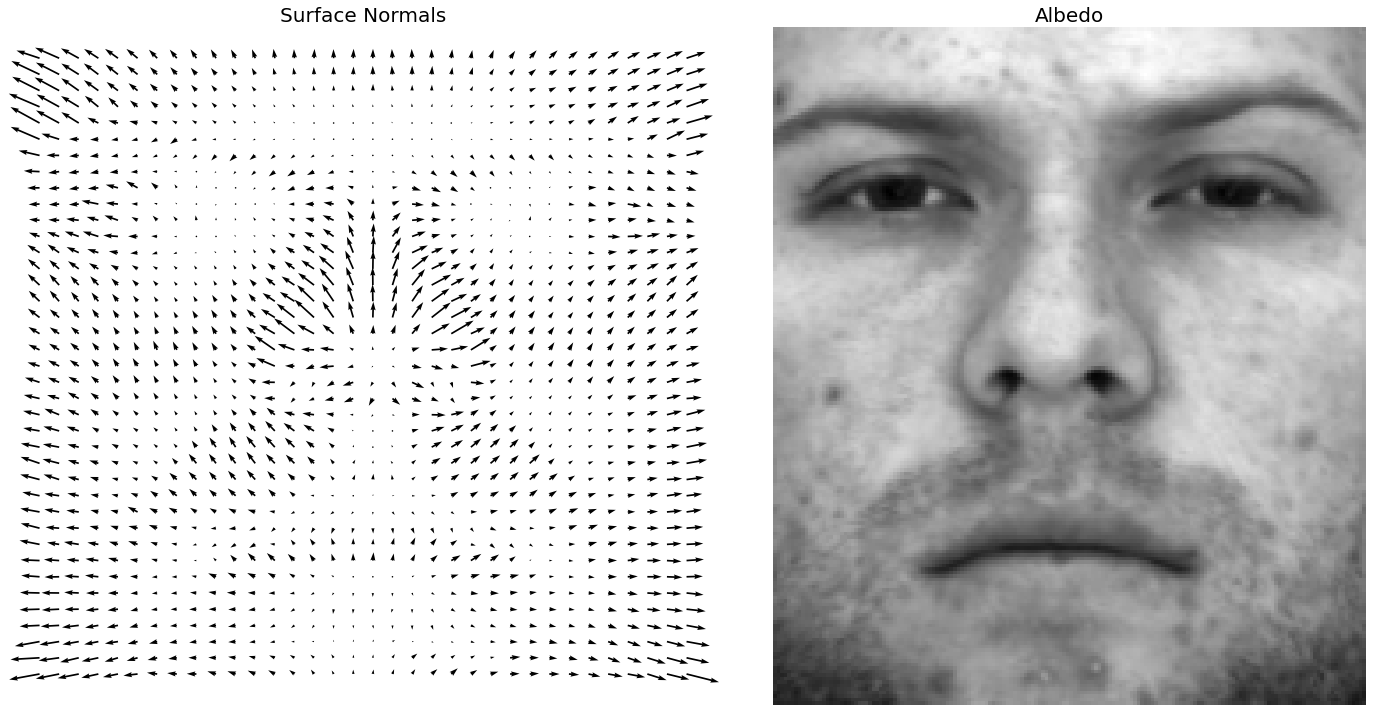

(192, 168) (192, 168, 3)


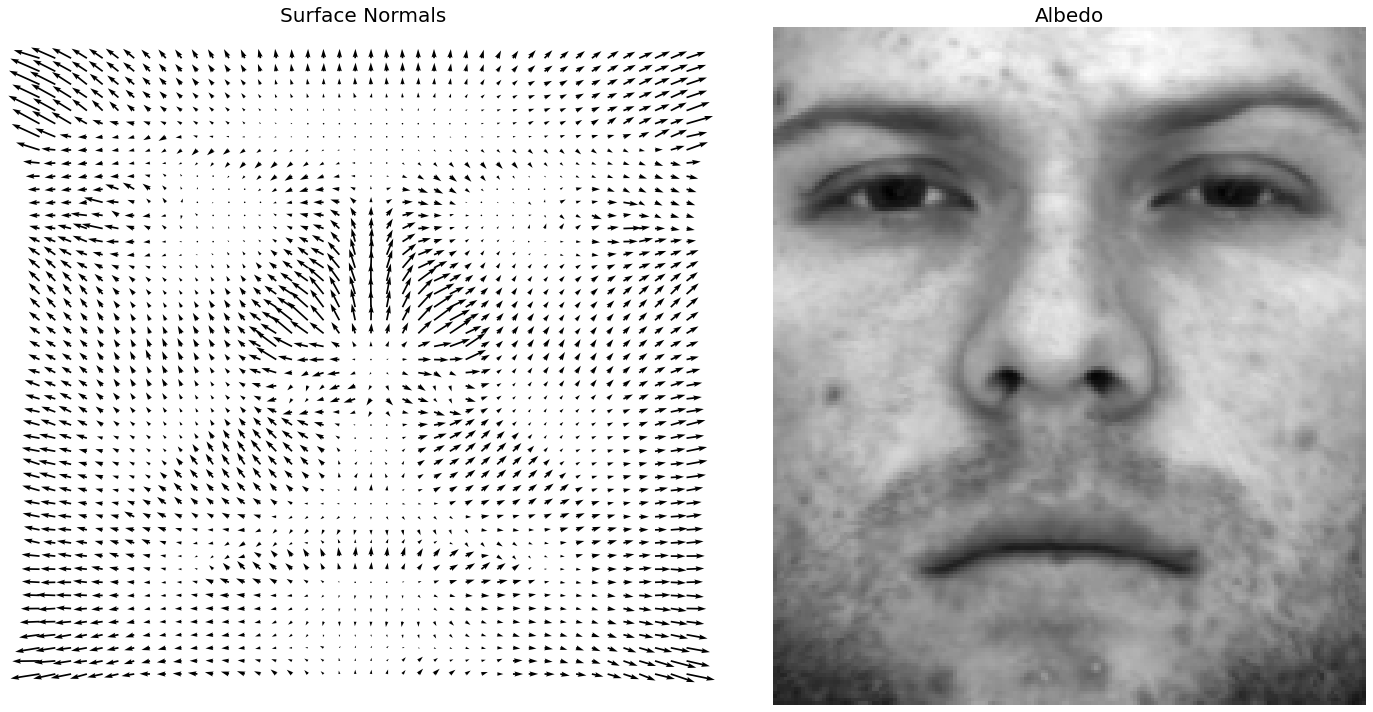

(192, 168) (192, 168, 3)


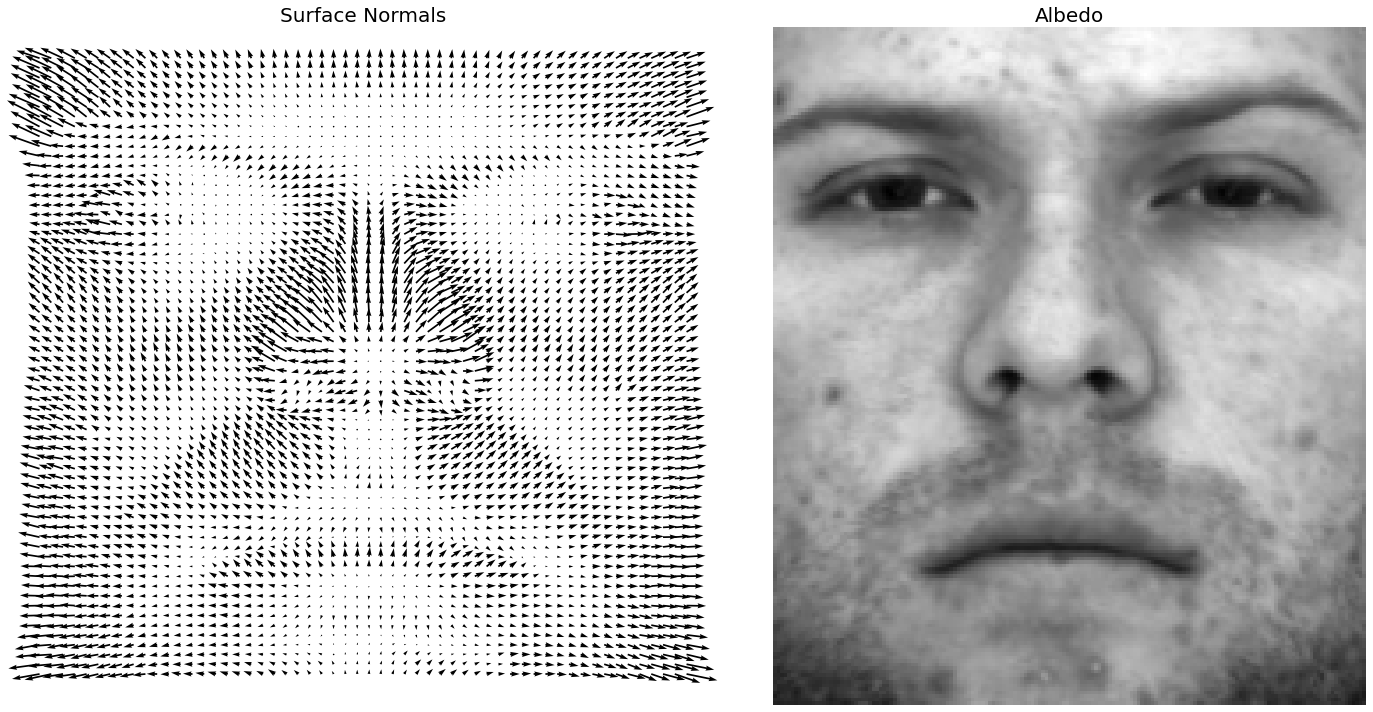

(192, 168) (192, 168, 3)


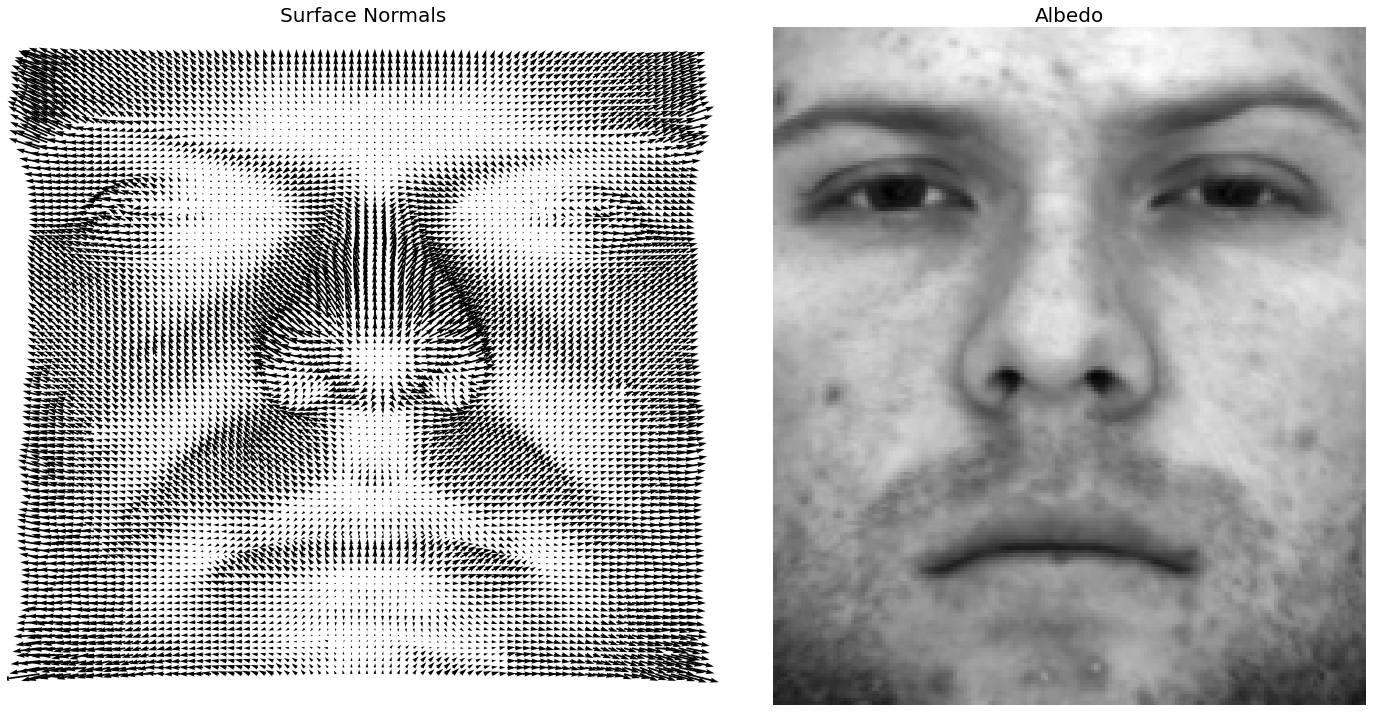

(192, 168) (192, 168, 3)


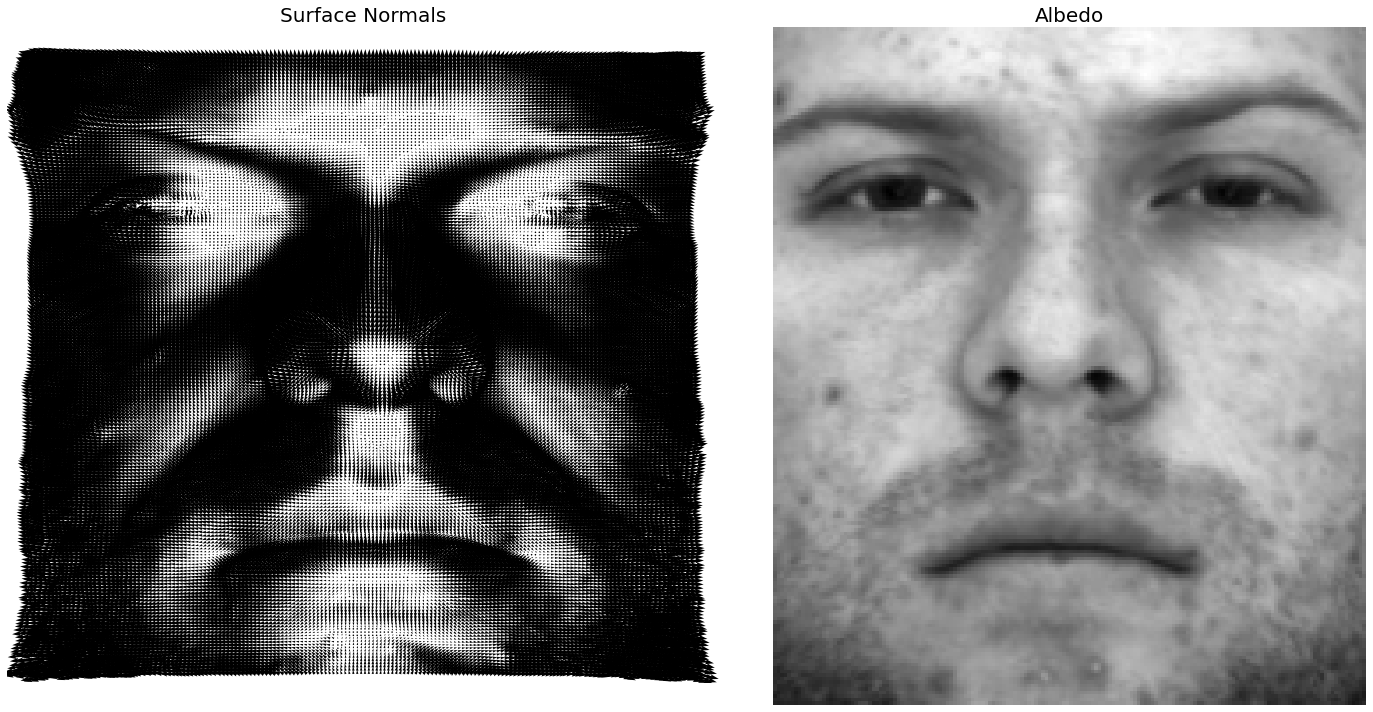

In [671]:
for k in range(10,0, -1):
    plot_surface_normals_albedo(surface_normals, albedo_image, k)

In [723]:
#albedo_image, surface_normals = photometric_stereo2(processed_imarray, light_dirs)
height_map = get_surface(surface_normals, 'fc')

In [720]:
height_map.min(), height_map.max()

(-217.84928258414476, 153.92003816787724)

In [773]:
from matplotlib import cm
from matplotlib.ticker import LinearLocator
from matplotlib.colors import LightSource

def plot_depth(h):

    fig, ax = plt.subplots(subplot_kw={"projection": "3d"}, figsize=(20,20))

    # Make data.
    X = np.arange(h.shape[1])
    Y = np.arange(h.shape[0])
    X, Y = np.meshgrid(X, Y)
    Z = np.flipud(np.fliplr(h))

    # Plot the surface.
    #light = LightSource(50, 50)
    #illuminated_surface = light.shade(Z, cmap=cm.inferno)
    ls = LightSource(azdeg=0, altdeg=65)
    greyvals = ls.shade(Z, plt.cm.Greys)

    surf = ax.plot_surface(X, Y, Z, cmap='gray',
                           linewidth=0.1, 
                           cstride=1,
                           rstride=1,
                           antialiased=False,
                           facecolors=greyvals) #illuminated_surface)
    # Customize the z axis.
    #ax.zaxis.set_major_locator(LinearLocator(10))
    # A StrMethodFormatter is used automatically
    #ax.zaxis.set_major_formatter('{x:.02f}')
    set_aspect_equal_3d(ax)
    #ax.set_zlim(0, 200)
    #ax.set_xlim(25, 120)

    # Add a color bar which maps values to colors.
    #fig.colorbar(surf, shrink=1, aspect=5)

    plt.show()

In [774]:
height_map = (height_map - height_map.min()) / (height_map.max() - height_map.min())

In [775]:
albedo_image = albedo_image / albedo_image.max()

In [776]:
#height_map[mask==0] = 0

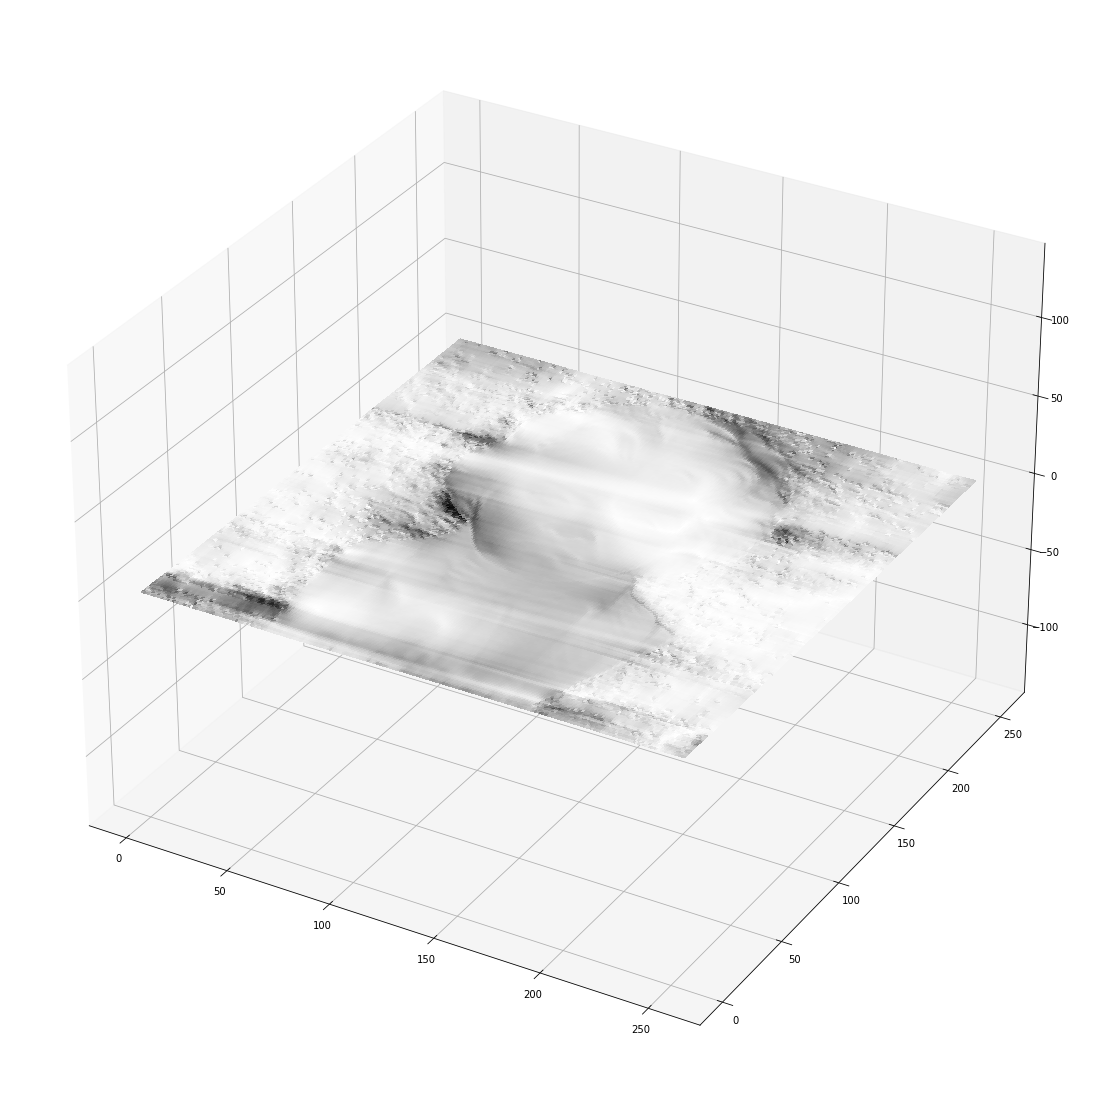

In [777]:
plot_depth(height_map)

C:\Users\Sandipan.Dey\anaconda3\lib\site-packages\ipykernel_launcher.py:27: MatplotlibDeprecationWarning: Calling gca() with keyword arguments was deprecated in Matplotlib 3.4. Starting two minor releases later, gca() will take no keyword arguments. The gca() function should only be used to get the current axes, or if no axes exist, create new axes with default keyword arguments. To create a new axes with non-default arguments, use plt.axes() or plt.subplot().


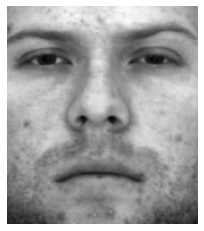

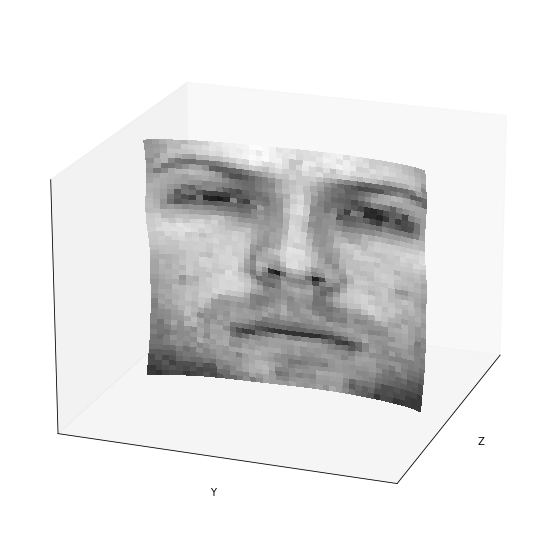

In [728]:
display_output(albedo_image, height_map)

In [520]:
height_map.min()

0.0

In [625]:
import numpy as np
from scipy import fftpack as fft
import scipy.sparse as sp
from scipy.sparse.linalg import spsolve
from scipy.io import loadmat
from matplotlib import pyplot as plt

def read_data_file(filename):
    """
    Read a matlab PS data file and returns
    - the images as a 3D array of size (m,n,nb_images)
    - the mask as a 2D array of size (m,n) with 
      mask > 0 meaning inside the mask
    - the light matrix S as a (nb_images, 3) matrix
    """
    data = loadmat(filename)
    I = data['I']
    mask = data['mask']
    S = data['S']
    return I, mask, S

I,mask,S = read_data_file("Data/Beethoven.mat") #Buddha
I.shape, mask.shape, S.shape

((256, 256, 3), (256, 256), (3, 3))

C:\Users\Sandipan.Dey\anaconda3\lib\site-packages\ipykernel_launcher.py:23: RuntimeWarning: invalid value encountered in true_divide
C:\Users\Sandipan.Dey\anaconda3\lib\site-packages\ipykernel_launcher.py:24: RuntimeWarning: invalid value encountered in true_divide
C:\Users\Sandipan.Dey\anaconda3\lib\site-packages\ipykernel_launcher.py:25: RuntimeWarning: invalid value encountered in true_divide


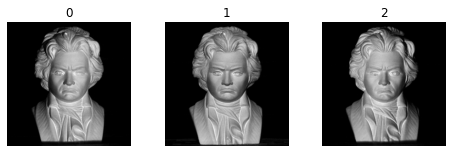

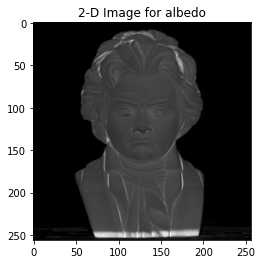

In [629]:
plt.figure(figsize=(8,5))
for i in range(I.shape[2]):
    plt.subplot(2,I.shape[2],i+1)
    plt.imshow(I[:,:,i],cmap= plt.cm.gray)
    plt.axis('off')
    plt.title(i)

#I_all = I.reshape(I.shape[0]*I.shape[1],10).T
I_all = np.vstack(
    (I[:,:,0].flatten(), I[:,:,1].flatten(), I[:,:,2].flatten()))


M = np.linalg.pinv(S).dot(I_all)
M_1 = M[0]
M_2 = M[1]
M_3 = M[2]

plt.figure()
rho = np.sqrt(M_1**2 + M_2**2 + M_3**2).reshape(I.shape[0],I.shape[1])
plt.imshow(rho,cmap = plt.cm.gray)
plt.title("2-D Image for albedo")

n_1 = (M_1 / rho.reshape(-1)).reshape(I.shape[0],I.shape[1])
n_2 = (M_2 / rho.reshape(-1)).reshape(I.shape[0],I.shape[1])
n_3 = (M_3 / rho.reshape(-1)).reshape(I.shape[0],I.shape[1])

In [630]:
albedo_image, surface_normals = photometric_stereo2(I, S)

C:\Users\Sandipan.Dey\anaconda3\lib\site-packages\ipykernel_launcher.py:29: RuntimeWarning: invalid value encountered in true_divide


(256, 256) (256, 256, 3)


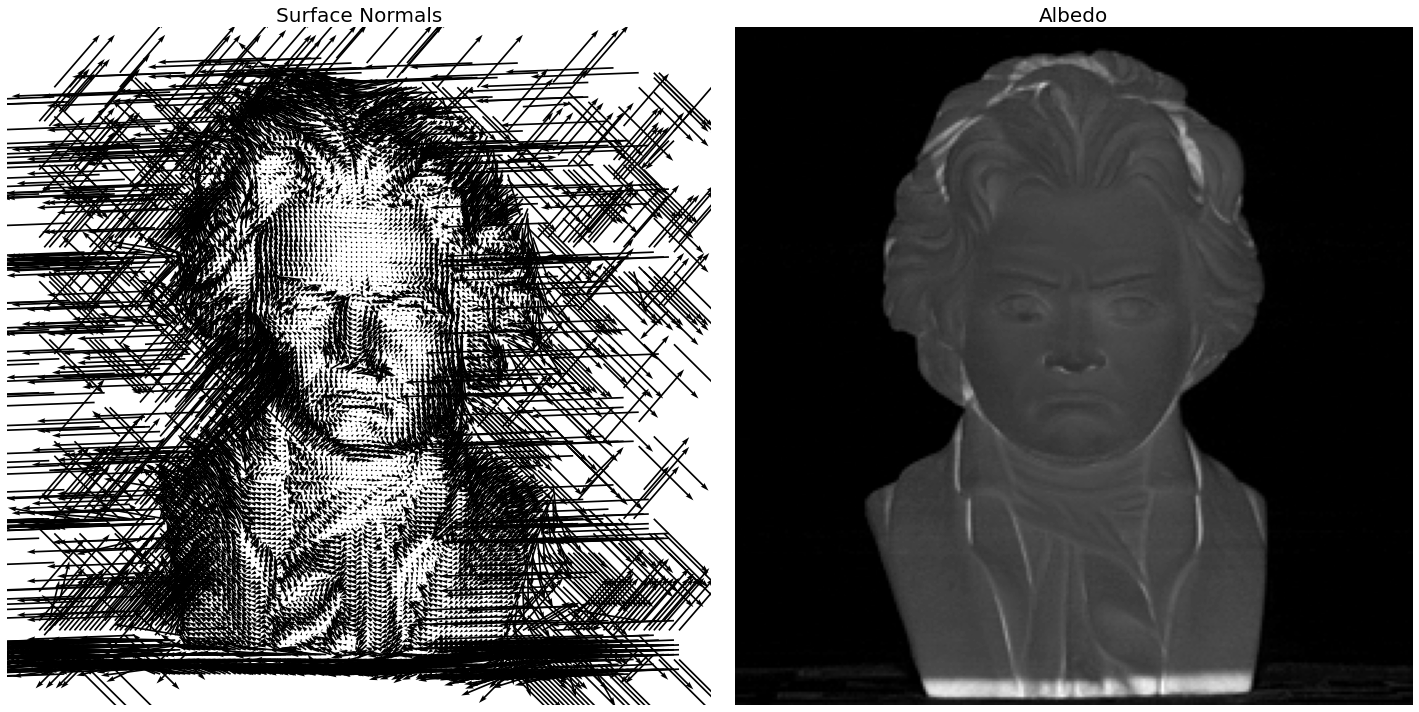

In [764]:
plot_surface_normals_albedo(surface_normals, albedo_image, 2)

In [765]:
surface_normals[np.isnan(surface_normals)] = 0

In [766]:
height_map = get_surface(surface_normals, 'fc')

In [779]:
height_map[mask == 0] = 0

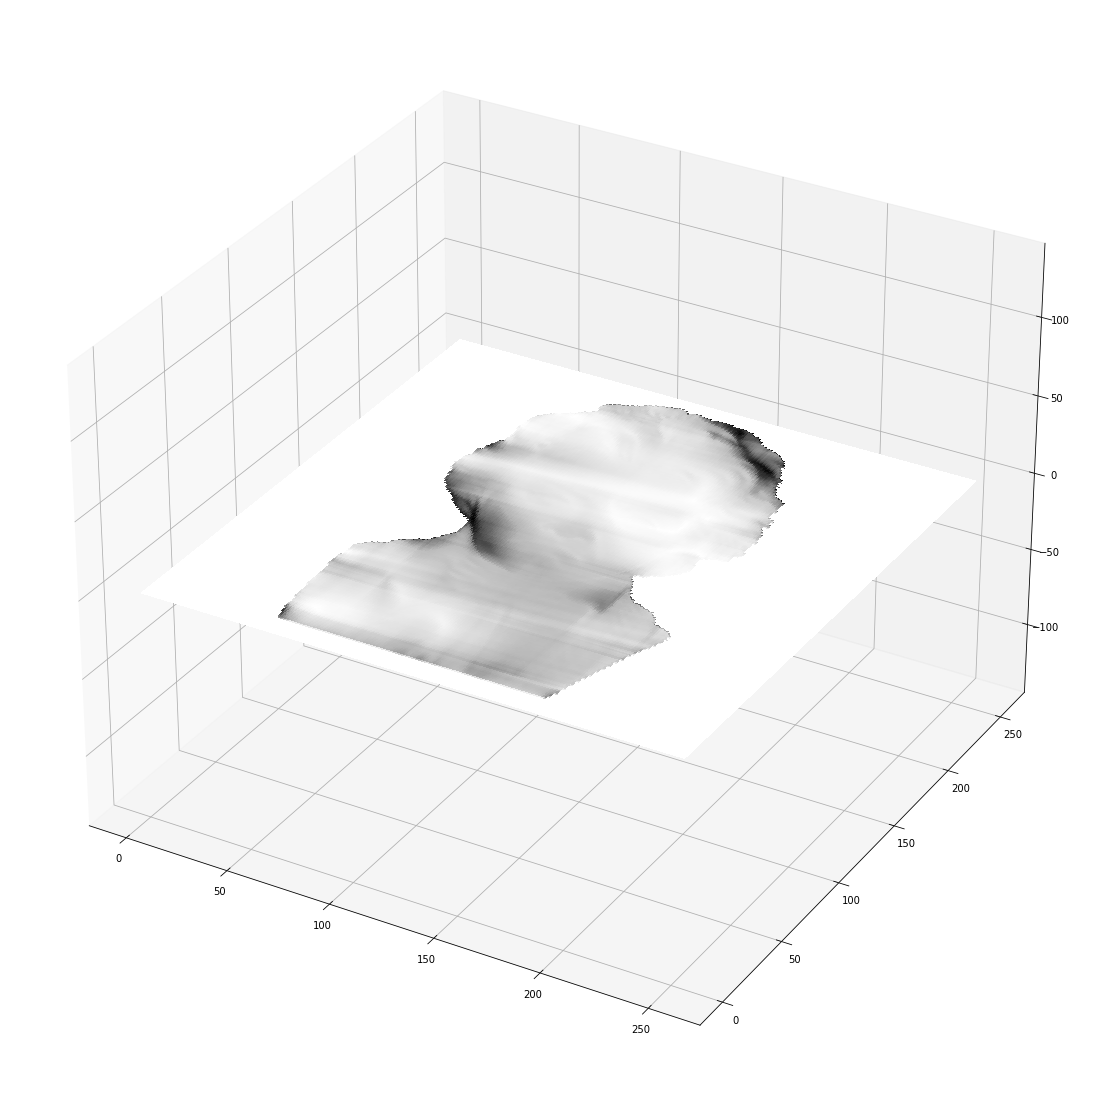

In [780]:
plot_depth(height_map)

In [636]:
n_1.shape, surface_normals.shape

((256, 256), (256, 256, 3))

In [637]:
surface_normals2 = np.zeros_like(surface_normals) #np.hstack((n_1, n_2, n_3))
surface_normals2[...,0] = n_1
surface_normals2[...,1] = n_2
surface_normals2[...,2] = n_3
surface_normals2.shape

(256, 256, 3)

(256, 256) (256, 256, 3)


C:\Users\Sandipan.Dey\anaconda3\lib\site-packages\ipykernel_launcher.py:8: RuntimeWarning: invalid value encountered in true_divide
  


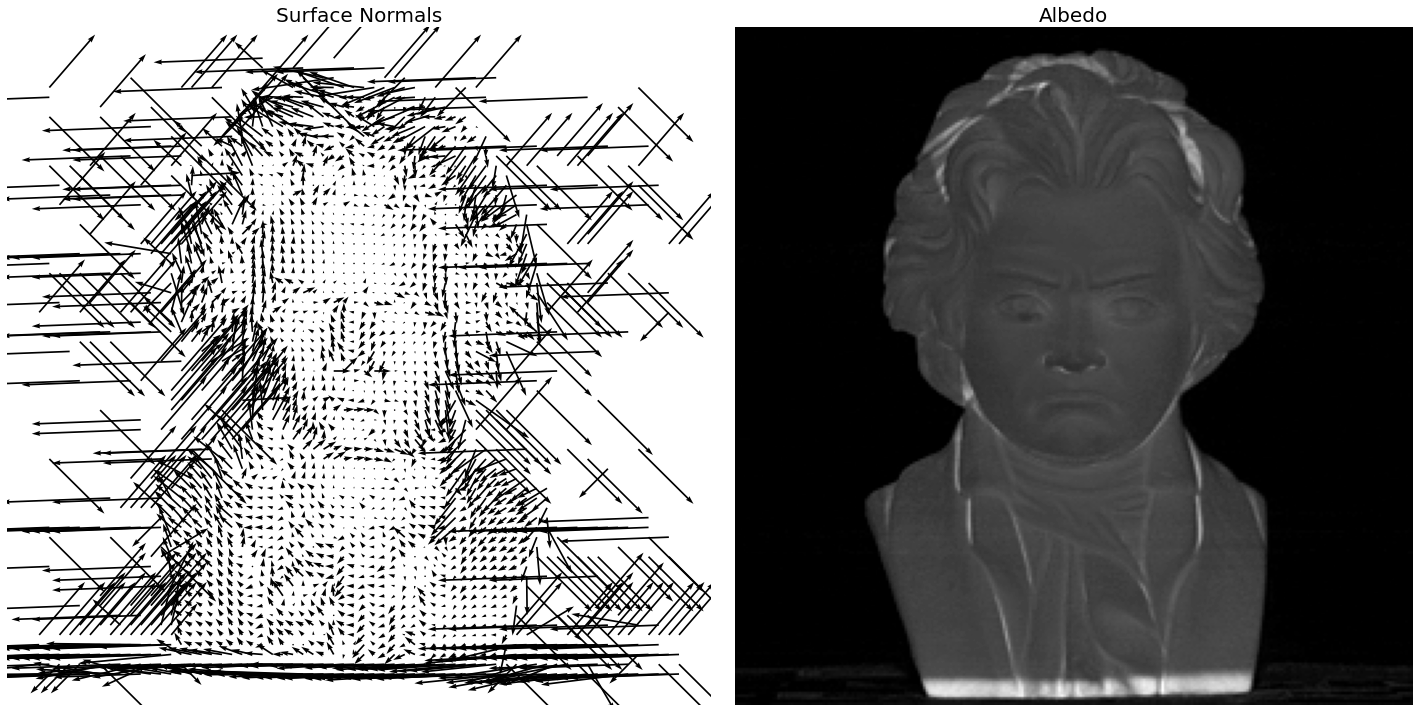

In [648]:
plot_surface_normals_albedo(surface_normals, rho, 4)

In [639]:
def cdx(f):
    """
    central differences for f-
    """
    m = f.shape[0]
    west = [0] + list(range(m-1))
    east = list(range(1,m)) + [m-1]
    return 0.5*(f[east,:] - f[west,:])
    
def cdy(f):
    """
    central differences for f-
    """
    n = f.shape[1]
    south = [0] + list(range(n-1))
    north = list(range(1,n)) + [n-1]
    return 0.5*(f[:,north] - f[:,south])

def sub2ind(shape, X, Y):
    """
    An equivalent of Matlab sub2ind, but without 
    argument checking and for dim 2 only.
    """    
    Z = np.array(zip(X,Y)).T
    shape = np.array(shape)
    indices = np.dot(shape, Z)
    indices.shape = indices.size
    return indices
    
def tolist(A):
    """
    Linearize array to a 1D list
    """
    return list(np.reshape(A, A.size))

def simchony_integrate(n1, n2, n3, mask):
    """
    Integration of the normal field recovered from observations onto 
    a depth map via Simchony et al. hybrid DCT / finite difference
    methods.
    
    Done by solving via DCT a finite difference equation discretizing
    the equation:
        Laplacian(z) - Divergence((n1/n3, n2/n3)) = 0
    under proper boundary conditions ("natural" boundary conditions on 
    a rectangular domain)
    
    Arguments:
    ----------
    n1, n2, n3: nympy float arrays 
        the 3 components of the normal field. They must be 2D arrays
        of size (m,n). Array (function) n3 should never be 0.
       
    Returns:
    --------
        z : depth map obtained by integration of the field -n1/n3, -n2/n3
        Set to nan outside the mask.
    """
    # first a bit paranoid, so check arguments
    if (type(n1) != np.ndarray) or (type(n2) != np.ndarray) or (type(n3) != np.ndarray):
        raise TypeError('One or more arguments are not numpy arrays.')
        
    if (len(n1.shape) != 2) or (len(n2.shape) != 2) or (len(n3.shape) != 2):
        raise TypeError('One or more arguments are not 2D arrays.')

    if (n1.shape != n2.shape) or (n1.shape != n3.shape):
        raise TypeError('Array dimensions mismatch.')

    try:
        n1 = n1.astype(float)
        n2 = n2.astype(float)
        n3 = n3.astype(float)
    except:
        raise TypeError('Arguments not all (convertible to) float.')
        
        
    # Hopefully on the safe side now
    m,n = n1.shape
        
    p = -n1/n3
    q = -n2/n3

    # divergence of (p,q)
    px = cdx(p)
    qy = cdy(q)
    
    f = px + qy      

    # 4 edges
    f[0,1:-1]  = 0.5*(p[0,1:-1] + p[1,1:-1])    
    f[-1,1:-1] = 0.5*(-p[-1,1:-1] - p[-2,1:-1])
    f[1:-1,0]  = 0.5*(q[1:-1,0] + q[1:-1,1])
    f[1:-1,-1] = 0.5*(-q[1:-1,-1] - q[1:-1,-2])

    # 4 corners
    f[ 0, 0] = 0.5*(p[0,0] + p[1,0] + q[0,0] + q[0,1])
    f[-1, 0] = 0.5*(-p[-1,0] - p[-2,0] + q[-1,0] + q[-1,1])
    f[ 0,-1] = 0.5*(p[0,-1] + p[1,-1] - q[0,-1] - q[1,-1])
    f[-1,-1] = 0.5*(-p[-1,-1] - p[-2,-1] -q[-1,-1] -q[-1,-2])

    # cosine transform f (reflective conditions, a la matlab, 
    # might need some check)
    fs = fft.dct(f, axis=0, norm='ortho')
    fs = fft.dct(fs, axis=1, norm='ortho')

    # check that this one works in a safer way than Matlab!
    x, y = np.mgrid[0:m,0:n]
    denum = (2*np.cos(np.pi*x/m) - 2) + (2*np.cos(np.pi*y/n) -2)
    Z = fs/denum
    Z[0,0] = 0.0 
    # or what Yvain proposed, it does not really matters
    # Z[0,0] = Z[1,0] + Z[0,1]
    
    z = fft.dct(Z, type=3, norm='ortho', axis=0)
    z = fft.dct(z, type=3, norm='ortho', axis=1)
    #out = np.where(mask == 0)
    #z[out] = np.nan
    return z

def unbiased_integrate(n1, n2, n3, mask, order=2):
    """
    Constructs the finite difference matrix, domain and other information
    for solving the Poisson system and solve it. Port of Yvain's implementation, 
    even  respecting the comments :-)
    
    Arguments:
    ----------
    n1, n2, n3, mask: numpy arrays
        all arrays must have the same size, say (m,n)
        n1, n2 and n3 are the three components of field of 
        normal vectors to the surface we want to reconstruct, obtained by 
        solving the system formed by the light sources and measured intensities,
        and then after albedo normalization.
        
    order: int
        default value of 2 is a good idea, don't change it
    
    Returns:
    -------
    z: numpy array
        array of size (m,n), with computed depth values inside the 
        make region (mask > 0) and NaN (Not a Number) in the region mask == 0.
    It solves for the system comming from the discretization of
           -Laplacian(z) - Divergence(n1/n3, n2/n3) = 0
    with some boundary conditions, it gives a discretized Poisson system
        AZ = b
    and z is obtained by mapping the values in Z to the region of the 2D image
    of size (m,n) where mask > 0. The rest of the z-image values are set to NaN.
    """

    p = -n1/n3
    q = -n2/n3

    # Calculate some usefuk masks
    m,n = mask.shape
    Omega = np.zeros((m,n,4))
    Omega_padded = np.pad(mask, (1,1), mode='constant', constant_values=0)
    Omega[:,:,0] = Omega_padded[2:,1:-1]*mask
    Omega[:,:,1] = Omega_padded[:-2,1:-1]*mask
    Omega[:,:,2] = Omega_padded[1:-1,2:]*mask
    Omega[:,:,3] = Omega_padded[1:-1,:-2]*mask
    del Omega_padded

    # Mapping    
    indices_mask = np.where(mask > 0)
    lidx = len(indices_mask[0])
    mapping_matrix = np.zeros(p.shape, dtype=int)
    mapping_matrix[indices_mask] = list(range(lidx))

    if order == 1:
        pbar = p.copy()
        qbar = q.copy()
    elif order == 2:
        pbar = 0.5*(p + p[list(range(1,m)) + [m-1], :])
        qbar = 0.5*(q + q[:, list(range(1,n)) + [n-1]])

    # System
    I = []
    J = []
    K = []
    b = np.zeros(lidx)


    # In mask, right neighbor in mask
    rset = Omega[:,:,2]
    X, Y = np.where(rset > 0)
    #indices_center = sub2ind(mask.shape, X, Y)
    I_center = mapping_matrix[(X,Y)].astype(int)
    #indices_neighbors = sub2ind(mask.shape, X, Y+1)
    I_neighbors = mapping_matrix[(X,Y+1)]
    lic = len(X)
    A_center = np.ones(lic)
    A_neighbors = -A_center
    K += tolist(A_center) + tolist(A_neighbors)
    I += tolist(I_center) + tolist(I_center)
    J += tolist(I_center) + tolist(I_neighbors)
    b[I_center] -= qbar[(X,Y)]

    #	In mask, left neighbor in mask
    lset = Omega[:,:,3]
    X, Y = np.where(lset > 0)
    #indices_center = sub2ind(mask.shape, X, Y)
    I_center = mapping_matrix[(X,Y)].astype(int)
    #indices_neighbors = sub2ind(mask.shape, X, Y-1)
    I_neighbors = mapping_matrix[(X,Y-1)]
    lic = len(X)
    A_center = np.ones(lic)
    A_neighbors = -A_center
    K += tolist(A_center) + tolist(A_neighbors)
    I += tolist(I_center) + tolist(I_center)
    J += tolist(I_center) + tolist(I_neighbors)
    b[I_center] += qbar[(X,Y-1)]


    # In mask, top neighbor in mask
    tset = Omega[:,:,1]
    X, Y = np.where(tset > 0)
    #indices_center = sub2ind(mask.shape, X, Y)
    I_center = mapping_matrix[(X,Y)].astype(int)
    #indices_neighbors = sub2ind(mask.shape, X-1, Y)
    I_neighbors = mapping_matrix[(X-1,Y)]
    lic = len(X)
    A_center = np.ones(lic)
    A_neighbors = -A_center
    K += tolist(A_center) + tolist(A_neighbors)
    I += tolist(I_center) + tolist(I_center)
    J += tolist(I_center) + tolist(I_neighbors)
    b[I_center] += pbar[(X-1,Y)]


    #	In mask, bottom neighbor in mask
    bset = Omega[:,:,0]
    X, Y = np.where(bset > 0)
    #indices_center = sub2ind(mask.shape, X, Y)
    I_center = mapping_matrix[(X,Y)].astype(int)
    #indices_neighbors = sub2ind(mask.shape, X+1, Y)
    I_neighbors = mapping_matrix[(X+1,Y)]
    lic = len(X)
    A_center = np.ones(lic)
    A_neighbors = -A_center
    K += tolist(A_center) + tolist(A_neighbors)
    I += tolist(I_center) + tolist(I_center)
    J += tolist(I_center) + tolist(I_neighbors)
    b[I_center] -= pbar[(X,Y)]

    # Construction de A : 
    A = sp.csc_matrix((K, (I, J)))
    A = A + sp.eye(A.shape[0])*1e-9
    z = np.nan*np.ones(mask.shape)
    z[indices_mask] = spsolve(A, b)
    return z


def display_depth_mayavi(z):
    """
    Display the computed depth function as a surface using 
    mayavi mlab.
    """
    from mayavi import mlab
    m, n = z.shape
    x, y = np.mgrid[0:m, 0:n]

    surf = mlab.mesh(x, y, z, colormap="gray")
    mlab.view(azimuth=0, elevation=90)
    surf.actor.property.interpolation = 'phong'
    surf.actor.property.specular = 0.1
    surf.actor.property.specular_power = 5
    mlab.show()

In [640]:
z = unbiased_integrate(n_1,n_2,n_3,mask)
#z = simchony_integrate(n_1,n_2,n_3,mask)

In [641]:
z[np.isnan(z)] = 0

In [642]:
def display_depth_matplotlib(z):
    """
    Same as above but using matplotlib instead.
    """
    from mpl_toolkits.mplot3d import Axes3D
    from matplotlib.colors import LightSource

    m, n = z.shape
    x, y = np.mgrid[0:m, 0:n]
    fig = plt.figure()
    ax = fig.gca(projection='3d')
    ls = LightSource(azdeg=0, altdeg=65)
    greyvals = ls.shade(z, plt.cm.Greys)
    ax.plot_surface(x, y, z, rstride=1, cstride=1, linewidth=0, antialiased=False, facecolors=greyvals)
    #set_aspect_equal_3d(ax)
    plt.axis('off')
    plt.axis('auto')
    plt.show()

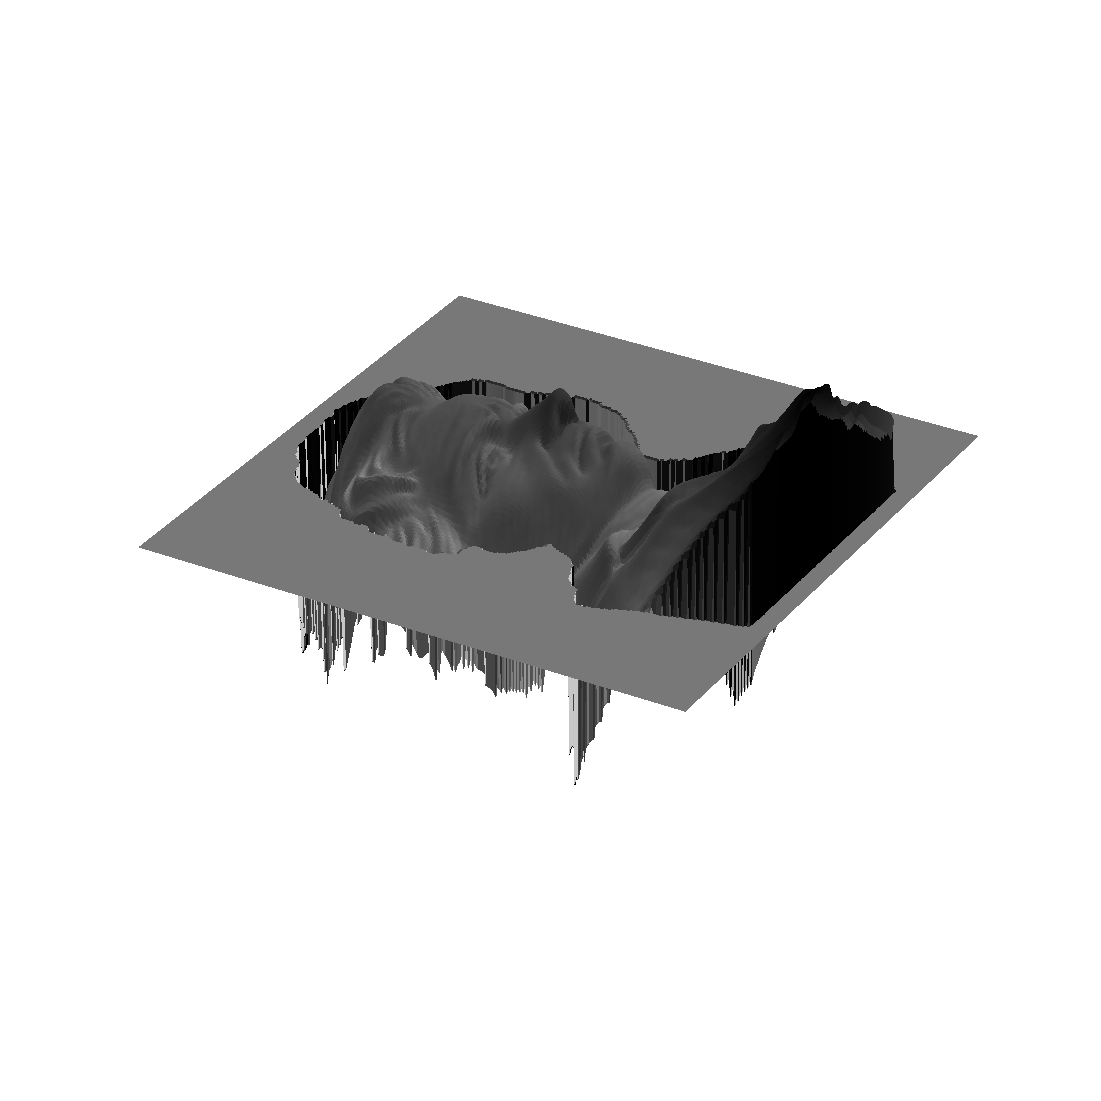

In [643]:
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.colors import LightSource

m, n = z.shape
x, y = np.mgrid[0:m, 0:n]
fig, ax = plt.subplots(subplot_kw={"projection": "3d"}, figsize=(20,20))
ls = LightSource(azdeg=0, altdeg=65)
greyvals = ls.shade(z, plt.cm.Greys)
ax.plot_surface(x, y, z, 
                rstride=1, cstride=1, 
                linewidth=0, antialiased=False, facecolors=greyvals)
#set_aspect_equal_3d(ax)
plt.axis('off')
#plt.axis('auto')
plt.show()

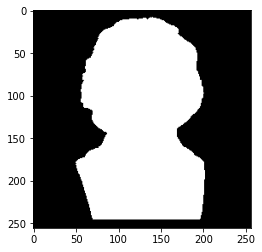

In [644]:
plt.imshow(mask)

In [ ]:
#display_depth_mayavi(z)

#plt.imshow()

In [810]:
def plot_surface_normals_albedo_depth(surface_normals, albedo_image, height_map, imf):
    """
    surface_normals: h x w x 3 matrix.
    """
    h, w, _ = surface_normals.shape
    x, y = np.meshgrid(np.arange(w), np.arange(h))
    print(x.shape, surface_normals.shape)
    p, q = surface_normals[:,:,0]/surface_normals[:,:,2], surface_normals[:,:,1]/surface_normals[:,:,2]
    for k in range(5, 0, -1):
        fig = plt.figure(figsize=(20,20))
        plt.gray()
        plt.subplots_adjust(0,0,1,0.95,0.05,0.05)
        ax = fig.add_subplot(2,2,1)
        plt.quiver(x[::k, ::k], y[::k, ::k], #np.flipud(np.fliplr(
                   np.flipud(np.fliplr(p[::k, ::k])), np.flipud(np.fliplr(q[::k, ::k])),  
                   units='xy', angles='xy', scale=0.25)
        plt.title('Surface Normals', size=20)
        plt.axis('off')
        ax = fig.add_subplot(2,2,2)
        plt.imshow(albedo_image)
        plt.axis('off')
        plt.title('Albedo', size=20)
        ax = fig.add_subplot(2,2,3, projection='3d')
        X = np.arange(height_map.shape[1])
        Y = np.arange(height_map.shape[0])
        X, Y = np.meshgrid(X, Y)
        Z = np.flipud(np.fliplr(height_map))
        ls = LightSource(azdeg=0, altdeg=65)
        greyvals = ls.shade(Z, plt.cm.Greys)
        surf = ax.plot_surface(X, Y, Z, cmap='coolwarm',
                               linewidth=0.1, 
                               cstride=1,
                               rstride=1,
                               antialiased=False,
                               facecolors=greyvals)
        set_aspect_equal_3d(ax)
        ax.set_title('Depth Map Reconstruction \n(with Frankot-Chellappa Algorrithm)',fontsize=20, color='k')
        plt.suptitle('Photometric Stereo', size=25)
        #plt.show()
        plt.savefig('out_{}_{:02d}.png'.format(imf, 5-k))
        plt.close()

In [811]:
def read_face(subject_name):
    root_path = 'croppedyale/'
    integration_method = 'average'
    full_path = '%s%s' % (root_path, subject_name)
    ambient_image, imarray, light_dirs = LoadFaceImages(full_path, subject_name, 64)
    print(imarray.shape, light_dirs.shape)
    return ambient_image, imarray, light_dirs

for imf in ['yaleB01', 'yaleB02', 'yaleB05', 'yaleB07']:
    ambient_image, imarray, light_dirs = read_face(imf)
    processed_imarray = preprocess(ambient_image, imarray)
    albedo_image, surface_normals = photometric_stereo2(processed_imarray, light_dirs)
    height_map = get_surface(surface_normals, 'fc')
    height_map[np.isnan(height_map)] = 0
    plot_surface_normals_albedo_depth(surface_normals, albedo_image, height_map, imf)

(192, 168, 64) (64, 3)
(192, 168) (192, 168, 3)
(192, 168, 64) (64, 3)
(192, 168) (192, 168, 3)
(192, 168, 64) (64, 3)
(192, 168) (192, 168, 3)
(192, 168, 64) (64, 3)
(192, 168) (192, 168, 3)


In [803]:
def plot_surface_normals_albedo_depth(surface_normals, albedo_image, height_map, mask, imf):
    """
    surface_normals: h x w x 3 matrix.
    """
    eps = 1e-4
    h, w, _ = surface_normals.shape
    x, y = np.meshgrid(np.arange(w), np.arange(h))
    print(x.shape, surface_normals.shape)
    p, q = surface_normals[:,:,0]/(surface_normals[:,:,2]+eps), surface_normals[:,:,1]/(surface_normals[:,:,2]+eps)
    for k in range(5, 0, -1):
        fig = plt.figure(figsize=(20,20))
        plt.gray()
        plt.subplots_adjust(0,0,1,0.95,0.05,0.05)
        ax = fig.add_subplot(2,2,1)
        plt.quiver(x[::k, ::k], y[::k, ::k], #np.flipud(np.fliplr(
                   np.flipud(np.fliplr(p[::k, ::k])), np.flipud(np.fliplr(q[::k, ::k])),  
                   units='xy', angles='xy', scale=0.25)
        plt.title('Surface Normals', size=20)
        plt.axis('off')
        ax = fig.add_subplot(2,2,2)
        plt.imshow(albedo_image)
        plt.axis('off')
        plt.title('Albedo', size=20)
        ax = fig.add_subplot(2,2,3, projection='3d')
        X = np.arange(height_map.shape[1])
        Y = np.arange(height_map.shape[0])
        X, Y = np.meshgrid(X, Y)
        Z = np.flipud(np.fliplr(height_map))
        ls = LightSource(azdeg=0, altdeg=65)
        greyvals = ls.shade(Z, plt.cm.Greys)
        surf = ax.plot_surface(X, Y, Z, cmap='coolwarm',
                               linewidth=0.1, 
                               cstride=1,
                               rstride=1,
                               antialiased=False,
                               facecolors=greyvals)
        set_aspect_equal_3d(ax)
        ax.set_title('Depth Map Reconstruction \n(with Unbiased Integration)',fontsize=20, color='k')
        ax = fig.add_subplot(2,2,4)
        plt.imshow(mask)
        plt.axis('off')
        #plt.axis('auto')
        plt.title('Mask', size=20)
        plt.suptitle('Photometric Stereo', size=25)
        #plt.show()
        plt.savefig('out_{}_{:02d}.png'.format(imf, 5-k))
        plt.close()

In [805]:
def read_data_file(filename):
    """
    Read a matlab PS data file and returns
    - the images as a 3D array of size (m,n,nb_images)
    - the mask as a 2D array of size (m,n) with 
      mask > 0 meaning inside the mask
    - the light matrix S as a (nb_images, 3) matrix
    """
    data = loadmat(filename)
    I = data['I']
    mask = data['mask']
    S = data['S']
    return I, mask, S

for imf in ['Beethoven', 'Buddha']:
    I, M, S = read_data_file('Data/' + imf)
    I[M==0] = 0
    S[np.isnan(S)] = 0
    albedo_image, surface_normals = photometric_stereo2(I, S)
    surface_normals[M==0] = 0
    height_map = unbiased_integrate(surface_normals[...,0],surface_normals[...,1],surface_normals[...,2],M)
    height_map[M==0] = -50
    plot_surface_normals_albedo_depth(surface_normals, albedo_image, height_map, M, imf)

C:\Users\Sandipan.Dey\anaconda3\lib\site-packages\ipykernel_launcher.py:151: RuntimeWarning: invalid value encountered in true_divide
C:\Users\Sandipan.Dey\anaconda3\lib\site-packages\ipykernel_launcher.py:152: RuntimeWarning: invalid value encountered in true_divide


(256, 256) (256, 256, 3)
(433, 650) (433, 650, 3)


In [808]:
for imf in ['yaleB01', 'yaleB02', 'yaleB05', 'yaleB07']:
    ambient_image, imarray, light_dirs = read_face(imf)
    plt.figure(figsize=(20,20))
    plt.gray()
    plt.subplots_adjust(0,0,1,0.95,0.05,0.05)
    for i in range(64):
        plt.subplot(8,8,i+1), plt.imshow(imarray[...,i]), plt.axis('off')
    plt.suptitle('Stereo images', size=25)
    plt.savefig('out_{}_00000.png'.format(imf))
    plt.close()

(192, 168, 64) (64, 3)
(192, 168, 64) (64, 3)
(192, 168, 64) (64, 3)
(192, 168, 64) (64, 3)


In [806]:
imarray.shape

(192, 168, 64)

In [816]:
imf = 'Beethoven' 
imf = 'Buddha'
I, M, S = read_data_file('Data/' + imf)
plt.figure(figsize=(20,20))
plt.gray()
plt.subplots_adjust(0,0,1,0.95,0.05,0.05)
for i in range(10):
    plt.subplot(4,3,i+1), plt.imshow(I[...,i]), plt.axis('off')
plt.suptitle('Stereo images', size=25)
plt.savefig('out_z{}_00000.png'.format(imf))
plt.close()